# Brain Connectivity Analysis

Load precision matrices (`iC`) and covariance matrices (`C`) for 4 methods. Nodes are grouped by anatomical position (Posterior / Central / Anterior / Midline) and permuted so groups are contiguous.

In [1]:
import os

# Must be set before any numerical library is imported
os.environ["OPENBLAS_NUM_THREADS"]   = "1"
os.environ["OMP_NUM_THREADS"]        = "1"
os.environ["MKL_NUM_THREADS"]        = "1"       # If using Intel MKL
os.environ["NUMEXPR_NUM_THREADS"]    = "1"   # If using NumExpr
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  # macOS Accelerate framework

# For Latex (get path from `which latex`)
latex_path = "/Library/TeX/texbin"
os.environ["PATH"] = latex_path+":" + os.environ["PATH"]

import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import sklearn.exceptions
from scipy.special import erfinv
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.notebook import tqdm
from types import SimpleNamespace
import pickle
import plotly.graph_objects as go
import nibabel as nib

from _util import *

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})

warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))
make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)

Error importing in API mode: ImportError("dlopen(/Users/dvegrod/Documents/GitHub/aquic/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <85D47EFD-9B5F-368A-BC00-EBCFE4080F31> /Users/dvegrod/Documents/GitHub/aquic/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


# Data Prep

In [2]:
# load data
# Label cortical parcels 0 to 360 with 0, and subcortical 460 to 718 with ones
labels = np.zeros(718, dtype=int)
labels[360:] = 1

loc = pickle.load(open("./data/fMRI/xyz.pkl", "rb"))["coord"]
pconn_img = nib.load('./data/fMRI/CortexSubcortex_ColeAnticevic_NetPartition_wSubcorGSR_CovarianceMatrix.pconn.nii') # <- PATH OF MATRIX, load nib package
S_true = pconn_img.get_fdata().astype(np.float64)
p = S_true.shape[0]
print(f"Matrix shape: {S_true.shape}")
Y = make_samples(cov=S_true, mean=None, n=int(p))

group_names = {
    0: "Cortex",
    1: "Subcortex",
}

# Color range for plotly
colors = ['#e41a1c', '#377eb8']

Matrix shape: (718, 718)


# Estimation

In [3]:
import os
import pickle
from functools import partial

iC = {}
C  = {}
nll = {}
runtimes={}

folder = "fMRI"
os.makedirs(f"./results/{folder}", exist_ok=True)

jobs = {
    "aquic-1": partial(compute_aquic, Y, c=1),
    "aquic-5": partial(compute_aquic, Y, c=5),
    "aquic-30": partial(compute_aquic, Y, c=30),
    "cv-glasso": partial(compute_glasso_cv, Y),
    "cv-quic": partial(compute_quic_cv, Y),
    "tiger": partial(compute_tiger, Y),
    "clime": partial(compute_clime, Y),
}

def run_method(name, func, folder, Y):
    path = f"./results/{folder}/{name}.pkl"

    if os.path.exists(path):
        with open(path, "rb") as f:
            res = pickle.load(f)
    else:
        res = func()
        with open(path, "wb") as f:
            pickle.dump(res, f)
    temp = -1.0 * sklearn.utils.extmath.fast_logdet(res.iC) + np.trace(res.iC @ S_true)  

    return res.iC, res.C, res.runtime, temp

for name, func in jobs.items():
    iC[name], C[name], runtimes[name],nll[name] = run_method(name, func, folder, Y)


methods = list(iC.keys())

## Partitioning and table of results

Using METIS to a bipartition of the brain.

In [4]:
import os                                                   
os.environ['METIS_DLL'] = '/opt/homebrew/lib/libmetis.dylib'

import networkx as nx
import metis
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from networkx.algorithms.community.quality import modularity, partition_quality
from scipy.optimize import linear_sum_assignment

k                   = len(group_names.keys())
records             = {}
all_clabels_matched = {}

clabels_set={}
A_set={}

for m in methods:

    D   = np.diag(1.0 / np.sqrt(np.diag(iC[m])))
    iCn =  D @ iC[m] @ D

    # the adjacency matrix A is the  abs( negative values of precision matrix )
    A = np.abs(np.minimum(iCn, 0.0))
    np.fill_diagonal(A, 0.0)

    A_set[m]=A

    G = nx.from_numpy_array(A)
    _, clabels = metis.part_graph(G, nparts=k, ubvec=[1.01],recursive=False, objtype='cut')
    clabels    = np.asarray(clabels, dtype=int)

    clabels_set[m]=clabels

    communities = [set(np.where(clabels == c)[0]) for c in range(k)]
    modularity_val = modularity(G, communities, weight="weight")

    # for each community, find the most common label_group value as the matched group
    comm_to_group = {}
    used = np.zeros(k,dtype=bool) # track already assigned groups, no double assigment                                          
    counts = []
    np.random.seed(seed=0)
    for x in range(k):
        idx                     = np.where(clabels == x)[0] # indices of nodes in community x
        vals                    = labels[idx] # their true group labels
        count_k                 = np.bincount(vals, minlength=k) + np.random.rand() #add random [0,1] so there are not ties
        counts.append(count_k)

    # counts_mat[i,j] is the number of correct classification if community "i" was mapped to group "j"
    counts_mat = np.array(counts)
    row_ind, col_ind = linear_sum_assignment(counts_mat, maximize=True)
    comm_to_group={}
    for x in range(k): 
        comm_to_group[row_ind[x]] = col_ind[x]

    clabels_matched        = np.array([comm_to_group[c] for c in clabels])
    all_clabels_matched[m] = clabels_matched

    # overall + per-group accuracy
    accuracy = (clabels_matched == labels).mean()

    records[m] = {
        'nnz/row iC':  round(np.count_nonzero(iCn - np.diag(np.diag(iCn))) / iCn.shape[0], 1),
        'nnz/row A':   round(np.count_nonzero(A) / A.shape[0], 1),
        'modularity':  round(modularity_val, 3),
        'accuracy':    round(accuracy, 3),
        'nll(x1E3)':   round(nll[m]/1000, 3),
        'runtime':     round(runtimes[m], 3),
    }

pd.DataFrame(records).T

,nnz/row iC,nnz/row A,modularity,accuracy,nll(x1E3),runtime
aquic-1,9.7,9.5,0.381,0.713,7.127,0.973
aquic-5,10.6,10.3,0.392,0.741,7.117,1.280
aquic-30,13.1,12.2,0.385,0.689,7.105,2.210
cv-glasso,6.6,6.6,0.020,0.514,7.191,58.279
cv-quic,32.2,24.9,0.314,0.680,7.091,57.910
tiger,7.5,7.3,0.372,0.638,7.188,30221.773
clime,3.9,1.2,0.001,0.564,7.434,4961.134


## Visualizations
Four cells

1. True partition of cortex and sub-cortex, spatial visualization
2. `log|iC|` (precision) and `log|C|` (covariance) for each method. Red lines mark group boundaries.
3. Paper figures
4. Spatial visualization of the partitioning of all considered estimators

In [5]:
# 3D plot
fig_gt = go.Figure()
for g in sorted(group_names.keys()):
    mask = labels == g
    fig_gt.add_trace(go.Scatter3d(
        x=loc[mask, 0], y=loc[mask, 1], z=loc[mask, 2],
        mode='markers',
        marker=dict(size=3, color=colors[g], opacity=0.8),
        name=group_names[g],
    ))

axis_off = dict(showticklabels=False, showgrid=False, zeroline=False, showbackground=False)
fig_gt.update_layout(
    title="True brain parcellation (label_group)",
    height=700, width=900,
    margin=dict(l=0, r=0, t=40, b=0),
    legend_title_text="Group",
    scene=dict(xaxis=axis_off, yaxis=axis_off, zaxis=axis_off),
)
fig_gt.show(renderer="browser")

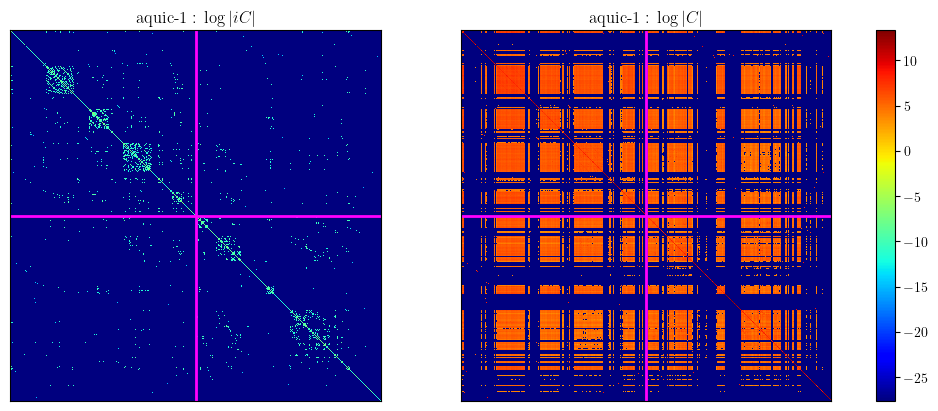

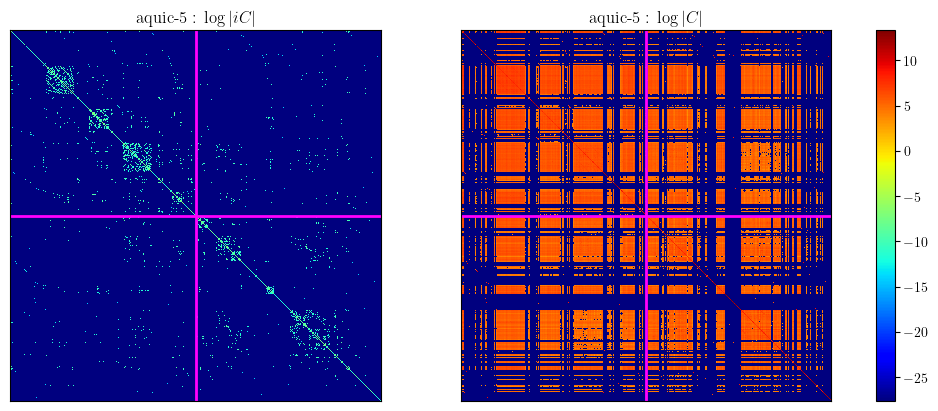

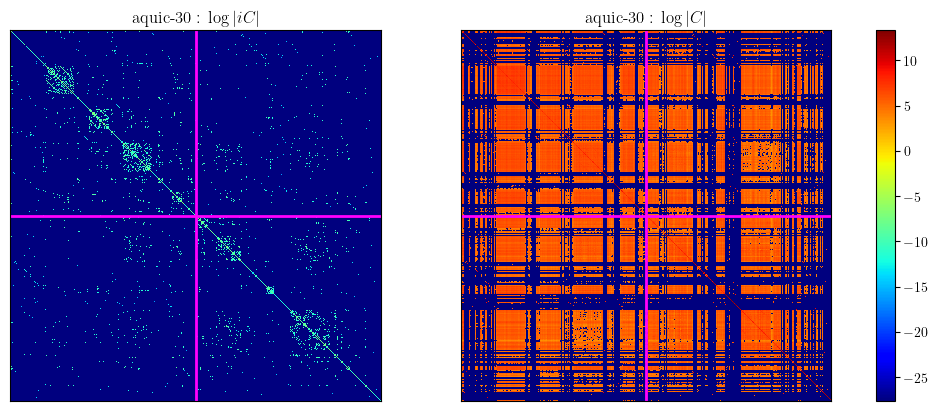

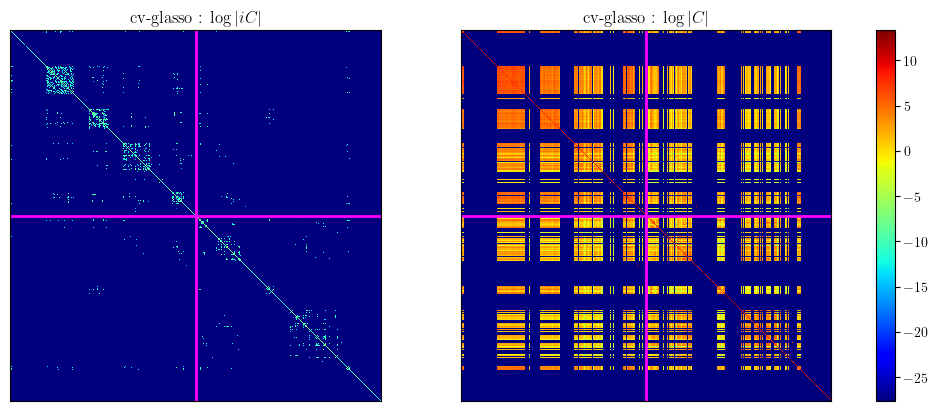

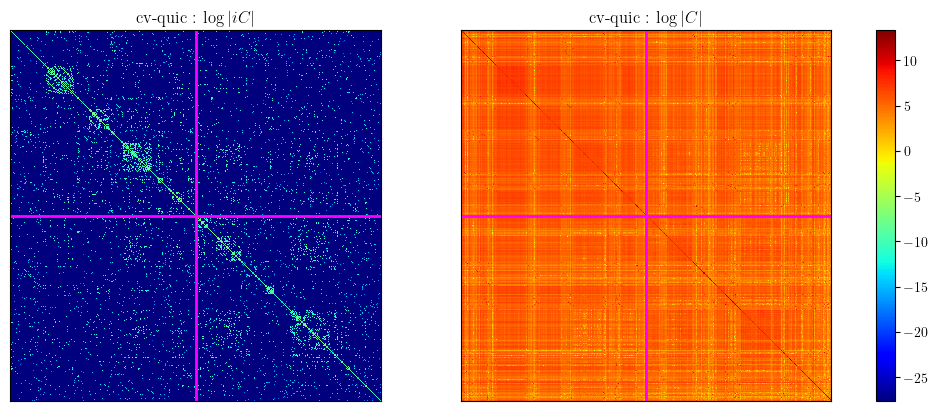

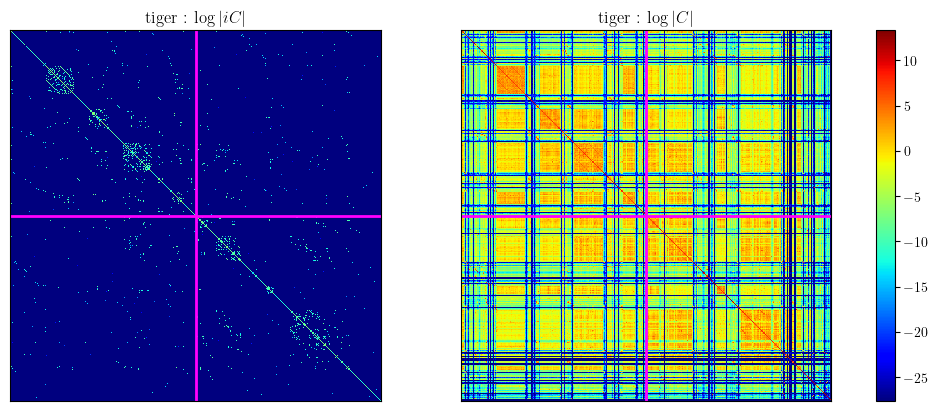

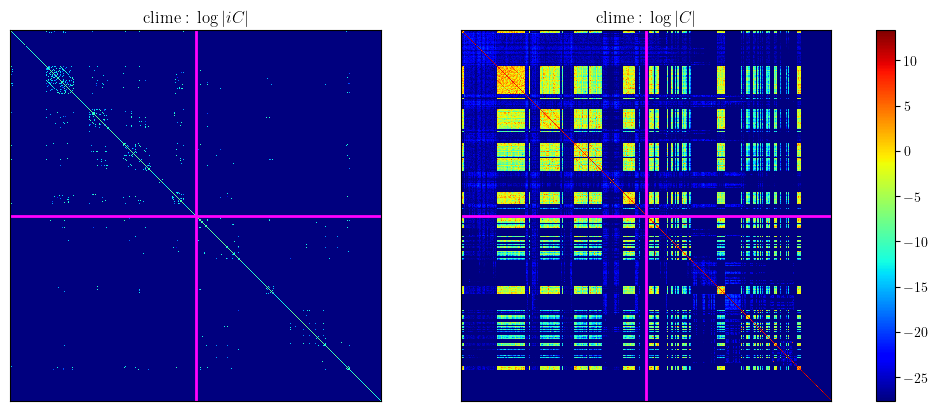

In [6]:
eps  = 1e-12
cmap = "jet"

# global limits for coloring
allv = []
for m in methods:
    allv.append(np.log(np.abs(iC[m]) + eps).ravel())
    allv.append(np.log(np.abs(C[m])  + eps).ravel())
allv = np.concatenate(allv)
vmin, vmax = np.nanmin(allv), np.nanmax(allv)


# plot precision, cov and class partitioning
boundaries = np.where(np.diff(labels))[0] + 0.5
for m in methods:
    Mi = np.log(np.abs(iC[m]) + eps)
    Mc = np.log(np.abs(C[m])  + eps)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    im0 = ax[0].imshow(Mi, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="none")
    ax[0].set_title(f"{m}  : $\log |iC|$")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    im1 = ax[1].imshow(Mc, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="none")
    ax[1].set_title(f"{m} : $\log |C|$")
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    for a in ax:
        for b in boundaries:
            a.axhline(b, color='magenta', linewidth=2)
            a.axvline(b, color='magenta', linewidth=2)

    fig.colorbar(im1, ax=ax)
    plt.show()

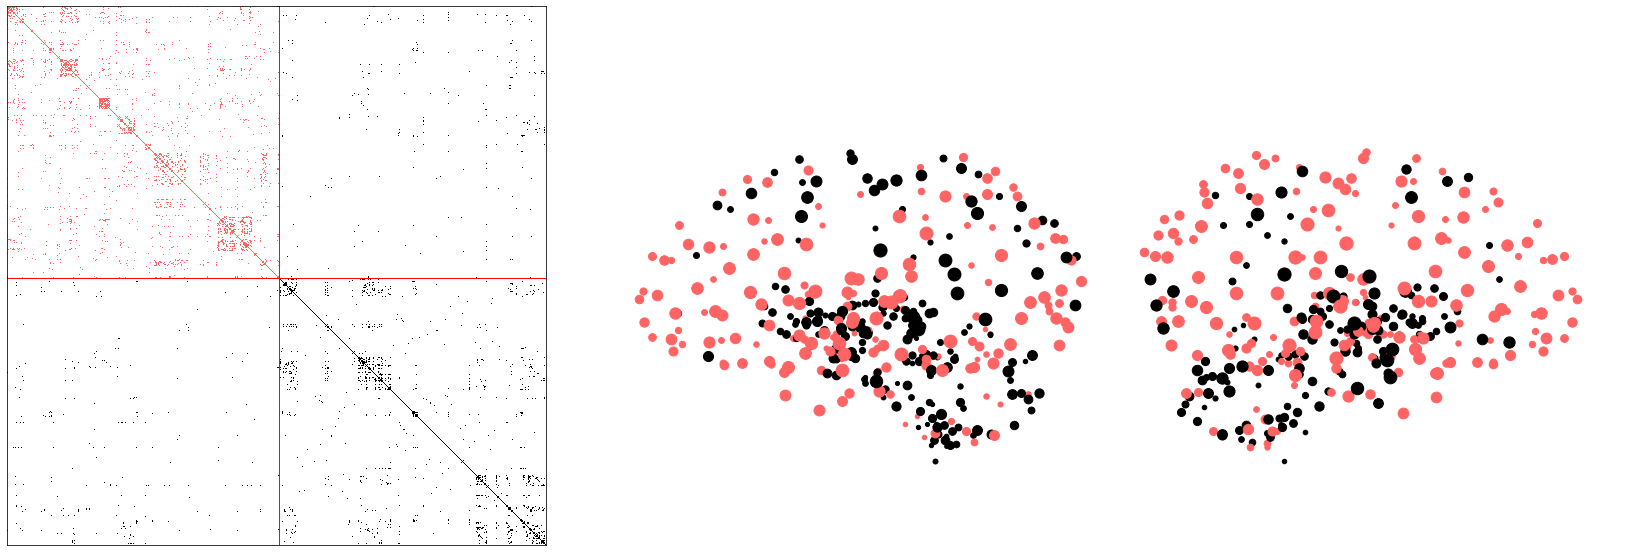

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

PLOTTED_METHOD = "aquic-5"

def plot_colored_adjacency_matrix(adj_matrix, node_labels, label_to_rgb, subfig = None):
    """
    Plot adjacency matrix with colored blocks for intra-region edges.

    Parameters:
    -----------
    adj_matrix : numpy.ndarray
        NxN adjacency matrix
    node_labels : list or numpy.ndarray
        Vector of length N with labels for each node
    label_to_rgb : dict
        Dictionary mapping labels to RGB tuples (values in [0,1])
    """
    n = len(adj_matrix)
    node_labels = np.array(node_labels)

    # Sort nodes by their labels to group same regions together
    sorted_indices = np.argsort(node_labels)
    sorted_adj =  adj_matrix[sorted_indices][:, sorted_indices]
    sorted_labels =  node_labels[sorted_indices]
    mmax = np.max(adj_matrix)
    mmin = np.min(adj_matrix)

    # Create a colored version of the adjacency matrix
    colored_matrix = np.ones((n, n, 3))

    for i in range(n):
        for j in range(n):
            if sorted_adj[i, j] != 0:  # If there's an edge
                if sorted_labels[i] == sorted_labels[j]:
                    # Intra-region edge: use region color
                    colored_matrix[i, j] = label_to_rgb[sorted_labels[i]]#, sorted_adj[i,j], mmax, mmin)
                else:
                    # Inter-region edge: use black
                    colored_matrix[i, j] = [0, 0, 0]
            else:
                # No edge: use white
                colored_matrix[i, j] = [1, 1, 1]


    # Plot
    if subfig is None:
        fig, ax = plt.subplots(figsize=(20, 20))
    else:
        fig, ax = subfig
    
    ax.imshow(colored_matrix, interpolation='nearest')

    # Add grid lines to separate regions
    unique_labels = []
    boundaries = [0]
    for i, label in enumerate(sorted_labels):
        if i == 0 or label != sorted_labels[i-1]:
            unique_labels.append(label)
            if i > 0:
                boundaries.append(i)
    boundaries.append(n)

    # Draw region boundaries
    for boundary in boundaries[1:-1]:
        ax.axhline(y=boundary-0.5, color='red', linewidth=1, alpha=1)
        ax.axvline(x=boundary-0.5, color='red', linewidth=1, alpha=1)

    ax.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off

    ax.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    left=False,      # ticks along the bottom edge are off
    right=False,         # ticks along the top edge are off
    ) # labels along the bottom edge are off
    # Add labels

    plt.tight_layout()
    return fig, ax

centers = loc.copy()

distance_sizer = lambda coord, minn, maxx, rmin, rmax : rmin + (rmax-rmin) * (coord - minn) / (maxx - minn)

tdiv = lambda x : (x[0] / 255, x[1] / 255, x[2] / 255)

def plot_brain_points(fig, centers, labels, label_info, elev, azim, flip=1):

    f, ax = fig
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plotted  = []

    xlimin = -200
    xlimax = 200
    ylimin = xlimin
    ylimax = xlimax
    zlimin = xlimin
    zlimax = xlimax
    
    # Get unique labels and create color map
    unique_labels = sorted(set(labels))
    n_partitions = len(unique_labels)
    color_map = {label: tdiv(label_info[label]["rgb"]) for i, label in enumerate(unique_labels,1)}

    # Assign colors to nodes based on their partition
    node_colors = [color_map[labels[node]] for node in range(len(centers))]#

    for i in range(centers.shape[0]):
        ax.scatter(centers[i, 0], centers[i, 1], centers[i, 2],
                                c=node_colors[i],  # Color by z-value
                                cmap='viridis',  # Color map
                                s=distance_sizer(centers[i,0] * flip, 0, 70, 20, 200),            # Point size
                                alpha=1)       # Transparency

    ax.view_init(elev=elev, azim=azim)


# Setup figure
fig = plt.figure(figsize=(24, 8), facecolor="white", dpi=70)
spec = mpl.gridspec.GridSpec(ncols=3, nrows=1)

# Setup subplots
ax1 = fig.add_subplot(spec[0, 0])
ax2 = fig.add_subplot(spec[0,1], projection="3d")
ax3 = fig.add_subplot(spec[0,2], projection="3d")

label_path = "data/fMRI/cortex_subcortex_parcel_network_assignments.txt"
labels = np.array([int(line.strip()) for line in open(label_path)]) + 1

# Separate hemispheres on two figures:
# Load the CSV file
df = pd.read_csv('data/fMRI/CortexSubcortex_ColeAnticevic_NetPartition_wSubcorGSR_parcels_LR_LabelKey_grouped.csv')
# Define the mapping: 'L' -> 0, 'R' -> 1, 'LR' -> 0
hemisphere_map = {'L': 0, 'R': 1, 'LR': 0}
# Apply the mapping and convert to integer array
mask = df['HEMISPHERE'].map(hemisphere_map).to_numpy(dtype=bool)
nmask = np.logical_not(mask)

labels = np.ones(718)
labels = all_clabels_matched[PLOTTED_METHOD]

label_info =  {
    0: {"name" : "CORTEX", "rgb" : (255,100,100)},
    1: {"name" : "SUBCORTEX", "rgb" : (0,0,0)},
}

#plot_brain_mesh((fig,ax1), )
plot_brain_points((fig,ax2), centers[nmask], labels[nmask], label_info, 0, 180, -1) # 180
plot_brain_points((fig,ax3), centers[mask], labels[mask], label_info, 0, 0, 1) # 0
f = lambda x: x
plot_colored_adjacency_matrix(f(iC[PLOTTED_METHOD]),  all_clabels_matched[PLOTTED_METHOD], dict([(k, tdiv(label_info[k]['rgb'])) for k in label_info.keys()]), subfig=(fig, ax1))

ax1.tick_params('y', which='both', bottom=False,left=False,top=False,right=False, labelleft=False)

ax2.axes.set_xlim3d(left=-60, right=60) 
ax2.axes.set_ylim3d(bottom=-70, top=60) 
ax2.axes.set_zlim3d(bottom=-40, top=80) 

ax3.axes.set_xlim3d(left=-60, right=60) 
ax3.axes.set_ylim3d(bottom=-70, top=60) 
ax3.axes.set_zlim3d(bottom=-40, top=80) 

ax2.set_axis_off()
ax3.set_axis_off()

plt.savefig("fig_brain.png", dpi=400)

In [8]:
import math

n_methods = len(methods)
n_cols    = math.ceil(math.sqrt(n_methods))
n_rows    = math.ceil(n_methods / n_cols)

specs = [[{'type': 'scatter3d'} for _ in range(n_cols)] for _ in range(n_rows)]
fig = make_subplots(
    rows=n_rows, cols=n_cols,
    specs=specs,
    subplot_titles=methods + [''] * (n_rows * n_cols - n_methods),
    horizontal_spacing=0.01,
    vertical_spacing=0.02,
)

for i, m in enumerate(methods):
    r, c = i // n_cols + 1, i % n_cols + 1
    cl   = all_clabels_matched[m]
    for g in range(k):
        mask = cl == g
        fig.add_trace(go.Scatter3d(
            x=loc[mask, 0], y=loc[mask, 1], z=loc[mask, 2],
            mode='markers',
            marker=dict(size=3, color=colors[g], opacity=0.8),
            name=group_names[g],
            legendgroup=group_names[g],
            showlegend=(i == 0),
        ), row=r, col=c)

axis_off = dict(showticklabels=False, showgrid=False, zeroline=False, showbackground=False)

fig.update_layout(
    height=300 * n_rows + 60,
    width=300 * n_cols,
    margin=dict(l=0, r=0, t=30, b=60),
    legend=dict(
        orientation='h',
        yanchor='top',
        y=-0.02,
        xanchor='center',
        x=0.5,
        title_text='group',
    ),
)
for idx in range(1, n_rows * n_cols + 1):
    scene = f"scene{'' if idx == 1 else idx}"
    fig.update_layout(**{scene: dict(xaxis=axis_off, yaxis=axis_off, zaxis=axis_off)})

fig.show(renderer="browser")